# Model Comparison with USGS Gauge Data

Extract a real HEC-RAS water-surface elevation (WSE) time series and compare it with the paired USGS gauge observations distributed with the Kalamazoo River model. This replaces the former unmatched Bald Eagle example. The saved run includes the central comparison, metrics, and plots; it reads delivered results without running HEC-RAS.

| Contract | This example |
|---|---|
| Model / results | USGS Kalamazoo River release, HEC-RAS 6.6 plan 41, channel Manning's n = 0.0315 |
| Gauge / location | USGS 04107850, Kalamazoo River near Allegan; named `gage` reference point in the model |
| Event | March 23–April 14, 2023; exact shared archive timestamps |
| Quantity | WSE in feet NGVD29 for both series; not raw gauge height |
| Inputs | Two original ScienceBase ZIP archives; lightweight online gauge-location metadata |
| Output | Source hashes, spatial/time/unit checks, nonempty paired table, metrics, and three-panel diagnostic figure |
| Evidence scope | Reproduces a published **calibration comparison** from delivered results; no independent validation event or new solver run |

The [USGS data release](https://doi.org/10.5066/P13CPA5B) supplies the results and observations. The [final USGS report](https://pubs.usgs.gov/publication/sir20265026/full) identifies the gauge, event, datum, and calibration role. See [220](https://rascommander.info/ras/notebooks/220_calibration_workflow/) for the distinct roughness-sensitivity workflow.

## Setup

Run with the repository's installed `ras-commander` and notebook dependencies. All `Hdf*` classes below are static namespaces. The default import mode uses the installed package; change the toggle only for local development. No HEC-RAS installation is needed for this delivered-results comparison.

In [1]:
USE_LOCAL_SOURCE = False
from pathlib import Path
import sys

if USE_LOCAL_SOURCE:
    for candidate in (Path.cwd(), Path.cwd().parent):
        if (candidate / "ras_commander" / "__init__.py").is_file():
            sys.path.insert(0, str(candidate))
            break

import hashlib
import logging
import os
import shutil
import zipfile
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pyproj import Geod

import ras_commander
from ras_commander import HdfBase, HdfBndry, HdfPlan, HdfResultsPlan, HdfResultsXsec
from ras_commander.sources.federal.usgs_sciencebase import UsgsScienceBase
from ras_commander.usgs import get_gauge_metadata
from ras_commander.usgs.metrics import nash_sutcliffe_efficiency

logging.getLogger("ras_commander").setLevel(logging.WARNING)
pd.set_option("display.max_colwidth", 90)
print("ras-commander:", ras_commander.__version__)

ras-commander: 0.102.1


## 1. Preserve the release and stage only the required files

Obtain `hec_ras_model.zip` and `calibration_data.zip` from the data release. Set `RAS_COMMANDER_922_RELEASE` to their containing directory, or let `UsgsScienceBase.download_model()` use `working/sciencebase`. The model archive is approximately 3.1 GB; ScienceBase may require its public download CAPTCHA. A download failure stops execution, rather than producing an apparently successful comparison with missing data.

Only plan 41's result HDF and the event CSV are copied to an ignored working directory. The pinned SHA-256 values identify the exact delivered files used here. ZIP member CRCs are checked by Python while reading; a different release requires explicit provenance review before changing the pins.

In [2]:
REPO_ROOT = next(
    candidate for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "pyproject.toml").exists() and (candidate / "ras_commander").is_dir()
)
DEFAULT_RELEASE = REPO_ROOT / "working" / "sciencebase" / "kalamazoo"
SOURCE_ROOT = Path(os.environ.get("RAS_COMMANDER_922_RELEASE", str(DEFAULT_RELEASE)))
WORK_ROOT = REPO_ROOT / "working" / "922_usgs_comparison"
WORK_ROOT.mkdir(parents=True, exist_ok=True)

if not all((SOURCE_ROOT / name).is_file() for name in ("hec_ras_model.zip", "calibration_data.zip")):
    if "RAS_COMMANDER_922_RELEASE" in os.environ:
        raise FileNotFoundError("Configured release directory must contain both original ZIP archives.")
    SOURCE_ROOT = UsgsScienceBase.download_model(
        "kalamazoo", output_dir=DEFAULT_RELEASE.parent, required_only=True, extract=False
    )

FILES = [
    ("hec_ras_model.zip", "hec_ras_model/kalamazoo_trowbridg.p41.hdf",
     "b33a3fb7fa775cd7672eebf2d5dca8b37f8278e71fc3eef335f8178a2bfb242c"),
    ("calibration_data.zip", "calibration_data/wse/wse_20230323_20230414.csv",
     "d4431b5c5f59556fcd9b1ce9b0b6c080e9808085ec61ed276c6c680fa6e89bf8"),
]
provenance = []
for archive_name, member_name, expected_sha256 in FILES:
    destination = WORK_ROOT / Path(member_name).name
    with zipfile.ZipFile(SOURCE_ROOT / archive_name) as archive:
        info = archive.getinfo(member_name)  # Exact member, never an arbitrary extraction path.
        if not destination.exists():
            temporary = destination.with_suffix(destination.suffix + ".partial")
            with archive.open(info) as source, temporary.open("wb") as target:
                shutil.copyfileobj(source, target)
            temporary.replace(destination)
    with destination.open("rb") as source:
        digest = hashlib.file_digest(source, "sha256").hexdigest()
    assert digest == expected_sha256, f"Release identity mismatch: {destination.name}"
    assert destination.stat().st_size == info.file_size
    provenance.append({"archive": archive_name, "member": member_name,
                       "bytes": info.file_size, "sha256": digest})

HDF_PATH = WORK_ROOT / Path(FILES[0][1]).name
OBSERVATION_PATH = WORK_ROOT / Path(FILES[1][1]).name
display(pd.DataFrame(provenance))

,archive,member,bytes,sha256
0,hec_ras_model.zip,hec_ras_model/kalamazoo_trowbridg.p41.hdf,307862128,b33a3fb7fa775cd7672eebf2d5dca8b37f8278e71fc3eef335f8178a2bfb242c
1,calibration_data.zip,calibration_data/wse/wse_20230323_20230414.csv,16612,d4431b5c5f59556fcd9b1ce9b0b6c080e9808085ec61ed276c6c680fa6e89bf8


## 2. Read plan identity, event, and result units

`HdfPlan.get_plan_information()` and `HdfResultsPlan.get_runtime_data()` inspect the delivered simulation. Runtime is historical model provenance, not time spent computing in this notebook. `HdfBase.get_result_unit_metadata()` rejects missing or contradictory HDF units. With a complete initialized project, use its project-unit metadata and `ras.plan_df['HDF_Results_Path']` as the path source instead.

The HDF establishes feet, while the release's `gage_wse_ft_NGVD29` column and the final report establish the vertical datum. Unit metadata alone never establishes a datum.

In [3]:
PLAN_NAME = "20230323_20230414_swe_0315_6278"
plan = HdfPlan.get_plan_information(HDF_PATH)
assert plan["Plan Name"] == PLAN_NAME
units = HdfBase.get_result_unit_metadata(HDF_PATH)
assert units["status"] == "resolved" and units["length_units"] == "ft"

display(pd.DataFrame([{
    "plan": plan["Plan Name"],
    "simulation_start": plan["Simulation Start Time"],
    "simulation_end": plan["Simulation End Time"],
    "saved_interval": plan["Base Output Interval"],
    "length_units": units["length_units"],
    "vertical_datum_source": "USGS release/report: NGVD29",
}]))
runtime = HdfResultsPlan.get_runtime_data(HDF_PATH)
display(runtime[["Plan Name", "Simulation Time (hr)", "Complete Process (hr)"]])

,plan,simulation_start,simulation_end,saved_interval,length_units,vertical_datum_source
0,20230323_20230414_swe_0315_6278,2023-03-23 01:00:00,2023-04-15,2HOUR,ft,USGS release/report: NGVD29


,Plan Name,Simulation Time (hr),Complete Process (hr)
0,20230323_20230414_swe_0315_6278,551.0,8.820738


## 3. Demonstrate the gauge-to-model location match

The report names station **04107850** for this event. Select the model's uniquely named `gage` point, not an inferred river-station number or the nearest point in an unrelated reach. Read its coordinates and containing mesh-cell ID from `HdfBndry.get_reference_points()`, then compare its WGS84 position with the current USGS site metadata.

The small coordinate separation is reported rather than treated as a hydraulic acceptance test. The named model point, report identity, and agreement with the released model-at-gauge series together support the pairing. Metadata can describe a gauge datum that differs from the historical release; this cell uses only site identity and horizontal location, never its current gauge-zero elevation.

In [4]:
SITE_ID = "04107850"
metadata = get_gauge_metadata(SITE_ID)
metadata_retrieved = datetime.now(timezone.utc).isoformat()
assert str(metadata["site_id"]) == SITE_ID
references = HdfBndry.get_reference_points(HDF_PATH)
selected = references.loc[references["Name"] == "gage"].copy()
assert len(selected) == 1 and selected.crs is not None
reference = selected.iloc[0]
reference_wgs84 = selected.to_crs("EPSG:4326").geometry.iloc[0]
_, _, distance_m = Geod(ellps="WGS84").inv(
    metadata["longitude"], metadata["latitude"], reference_wgs84.x, reference_wgs84.y
)

display(pd.DataFrame([{
    "site_id": SITE_ID, "station_name": metadata["station_name"],
    "USGS_latitude": metadata["latitude"], "USGS_longitude": metadata["longitude"],
    "model_latitude": reference_wgs84.y, "model_longitude": reference_wgs84.x,
    "separation_m": distance_m, "reference_name": reference["Name"],
    "mesh": reference["mesh_name"], "cell_id": int(reference["Cell Index"]),
    "USGS_metadata_retrieved_UTC": metadata_retrieved,
}]))

2026-09-26 09:18:01 - httpx - INFO - HTTP Request: GET https://waterservices.usgs.gov/nwis/site?sites=04107850&siteOutput=Expanded&format=rdb "HTTP/1.1 200 "


,site_id,station_name,USGS_latitude,USGS_longitude,model_latitude,model_longitude,separation_m,reference_name,mesh,cell_id,USGS_metadata_retrieved_UTC
0,04107850,"KALAMAZOO RIVER NEAR ALLEGAN, MI",42.482256,-85.798355,42.482432,-85.798435,20.654542,gage,perimeter_1,29613,2026-09-26T13:18:01.995193+00:00


## 4. Extract modeled WSE and read the paired observations

`HdfResultsXsec.get_ref_points_timeseries()` is the public static API for this 2D reference point. For a 1D model, use `HdfResultsXsec.get_xsec_timeseries()` and select its explicit `River`, `Reach`, and `Station` coordinates after documenting the spatial match.

The CSV contains observed WSE independently of its modeled columns. Read `gage_wse_ft_NGVD29` directly; do not manufacture observations by adding noise or subtracting a modeled residual. The released modeled column is used only as an extraction cross-check.

The CSV and HDF have a shared, timezone-naive archive clock. Their time-zone definition is not supplied in these files, so this reproduction keeps that clock without labeling it UTC or converting it to local time. A new NWIS query would require independent time-zone and historical datum reconciliation; [911](https://rascommander.info/ras/notebooks/911_usgs_gauge_data_integration/) and [921](https://rascommander.info/ras/notebooks/921_usgs_study_package_from_primitives/) cover acquisition and study packaging.

In [5]:
results = HdfResultsXsec.get_ref_points_timeseries(HDF_PATH, variables="Water Surface")
point_series = results["Water Surface"].sel(refpt_id=int(reference["refpt_id"]))
assert point_series.coords["refpt_name"].item() == "gage"
assert point_series.coords["mesh_name"].item() == reference["mesh_name"]
assert point_series.attrs["units"] == "ft"
modeled = point_series.to_series().rename("modeled").rename_axis("datetime").reset_index()

released = pd.read_csv(OBSERVATION_PATH)
released["datetime"] = pd.to_datetime(released["Date"] + " " + released["Time"])
observed = released[["datetime", "gage_wse_ft_NGVD29", "wse_ft_" + PLAN_NAME]].rename(
    columns={"gage_wse_ft_NGVD29": "observed", "wse_ft_" + PLAN_NAME: "released_modeled"}
)
assert modeled["datetime"].dt.tz is None and observed["datetime"].dt.tz is None
assert modeled["datetime"].is_unique and observed["datetime"].is_unique
assert modeled["datetime"].is_monotonic_increasing
assert observed["datetime"].is_monotonic_increasing

# Exact matching: no nearest-time tolerance, interpolation, resampling, or silent dropping.
aligned = observed.merge(modeled, on="datetime", how="outer", validate="one_to_one", indicator=True)
assert aligned["_merge"].eq("both").all(), "Unmatched event timestamps require review."
aligned = aligned.drop(columns="_merge").sort_values("datetime").reset_index(drop=True)
assert len(aligned) >= 3
assert np.isfinite(aligned[["observed", "modeled", "released_modeled"]].to_numpy()).all()
assert aligned["datetime"].min() >= pd.Timestamp(plan["Simulation Start Time"])
assert aligned["datetime"].max() <= pd.Timestamp(plan["Simulation End Time"])

extraction_delta = (aligned["modeled"] - aligned["released_modeled"]).abs()
# CSV precision is 0.001 ft; allow half that plus one native float32 ULP.
rounding_tolerance = 0.0005 + float(np.spacing(point_series.values).max())
assert extraction_delta.max() <= rounding_tolerance, "Extracted values disagree with release rounding."
print(f"Exact paired records: {len(aligned)} / {len(modeled)} modeled / {len(observed)} observed")
print(f"Period: {aligned.datetime.min()} to {aligned.datetime.max()} (archive clock)")
print(f"Largest HDF versus released-model difference: {extraction_delta.max():.6f} ft")
display(aligned.head())

Exact paired records: 276 / 276 modeled / 276 observed
Period: 2023-03-23 01:00:00 to 2023-04-14 23:00:00 (archive clock)
Largest HDF versus released-model difference: 0.000531 ft


,datetime,observed,released_modeled,modeled
0,2023-03-23 01:00:00,647.133,643.620,643.619690
1,2023-03-23 03:00:00,647.123,647.251,647.251404
2,2023-03-23 05:00:00,647.123,647.252,647.251770
3,2023-03-23 07:00:00,647.143,647.269,647.269165
4,2023-03-23 09:00:00,647.173,647.300,647.300415


## 5. Calculate event diagnostics without an automatic model rating

RMSE, MAE, and bias retain the WSE unit (ft). Residual and bias use **modeled minus observed**. NSE compares squared error with the observed mean predictor; it is 1 for identical series and 0 when those squared errors equal the observed-mean benchmark. It is not a project acceptance criterion.

Do not apply universal discharge-performance tiers to WSE. In particular, PBIAS and the mean/variability ratios in KGE depend on the elevation origin: shifting an elevation datum can change them without changing the physical errors. This notebook therefore reports WSE errors and NSE rather than a PBIAS/KGE rating. For a justified discharge comparison, the library's PBIAS convention remains `100 * sum(modeled - observed) / sum(observed)`, positive for overestimation.

All paired records, including the first saved model state, enter the primary metrics. There is no hidden warm-up exclusion or parameter optimization.

In [6]:
aligned["residual_ft"] = aligned["modeled"] - aligned["observed"]
residual = aligned["residual_ft"].to_numpy()
metrics = {
    "paired_records": len(aligned),
    "rmse_ft": float(np.sqrt(np.mean(residual ** 2))),
    "mae_ft": float(np.mean(np.abs(residual))),
    "bias_ft_modeled_minus_observed": float(np.mean(residual)),
    "nse": nash_sutcliffe_efficiency(aligned["observed"], aligned["modeled"]),
    "maximum_absolute_error_ft": float(np.max(np.abs(residual))),
}
assert all(np.isfinite(value) for value in metrics.values())
display(pd.DataFrame([metrics]))

observed_peak = aligned.loc[aligned["observed"].idxmax()]
modeled_peak = aligned.loc[aligned["modeled"].idxmax()]
display(pd.DataFrame([{
    "observed_peak_WSE_ft_NGVD29": observed_peak["observed"],
    "modeled_peak_WSE_ft_NGVD29": modeled_peak["modeled"],
    "peak_WSE_difference_ft": modeled_peak["modeled"] - observed_peak["observed"],
    "observed_peak_archive_time": observed_peak["datetime"],
    "modeled_peak_archive_time": modeled_peak["datetime"],
    "sampled_peak_timing_difference_hours":
        (modeled_peak["datetime"] - observed_peak["datetime"]).total_seconds() / 3600,
}]))
print("Largest-error records (retained in all metrics):")
display(aligned.loc[aligned.residual_ft.abs().nlargest(3).index,
                    ["datetime", "observed", "modeled", "residual_ft"]])

,paired_records,rmse_ft,mae_ft,bias_ft_modeled_minus_observed,nse,maximum_absolute_error_ft
0,276,0.265002,0.171336,0.145877,0.914632,3.51331


,observed_peak_WSE_ft_NGVD29,modeled_peak_WSE_ft_NGVD29,peak_WSE_difference_ft,observed_peak_archive_time,modeled_peak_archive_time,sampled_peak_timing_difference_hours
0,650.603,650.752563,0.149563,2023-04-06 01:00:00,2023-04-06 01:00:00,0.0


Largest-error records (retained in all metrics):


,datetime,observed,modeled,residual_ft
0,2023-03-23 01:00:00,647.133,643.619690,-3.513310
200,2023-04-08 17:00:00,649.253,649.445374,0.192374
202,2023-04-08 21:00:00,649.223,649.411133,0.188133


## 6. Inspect the time series, scatter, and residuals

The plots show this particular plan and event at the named gauge point. Peak timing is measured only on the saved two-hour samples; it does not establish sub-hour timing accuracy. The first saved-state discrepancy stays visible in the plot and metrics.

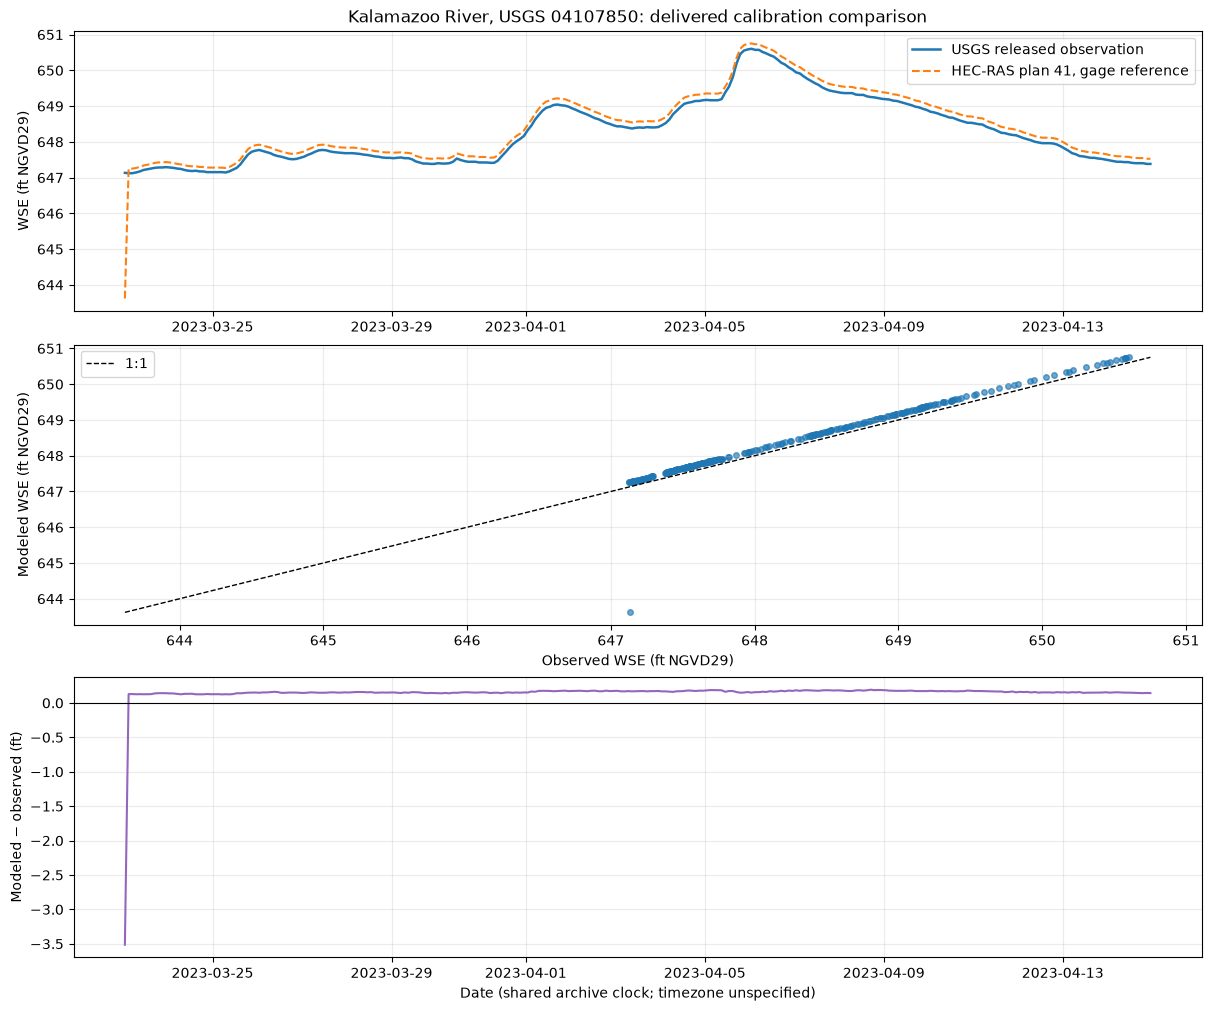

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)
axes[0].plot(aligned.datetime, aligned.observed, label="USGS released observation", linewidth=1.8)
axes[0].plot(aligned.datetime, aligned.modeled, "--", label="HEC-RAS plan 41, gage reference")
axes[0].set(ylabel="WSE (ft NGVD29)", title=f"Kalamazoo River, USGS {SITE_ID}: delivered calibration comparison")
axes[0].legend()
axes[1].scatter(aligned.observed, aligned.modeled, s=16, alpha=0.65)
limits = [aligned[["observed", "modeled"]].min().min(), aligned[["observed", "modeled"]].max().max()]
axes[1].plot(limits, limits, "k--", linewidth=1, label="1:1")
axes[1].set(xlabel="Observed WSE (ft NGVD29)", ylabel="Modeled WSE (ft NGVD29)")
axes[1].legend()
axes[2].plot(aligned.datetime, aligned.residual_ft, color="tab:purple")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set(xlabel="Date (shared archive clock; timezone unspecified)", ylabel="Modeled − observed (ft)")
for ax in axes:
    ax.grid(alpha=0.25)
plt.show()

## 7. Save a reviewable comparison and state its limits

These outputs demonstrate a real, nonempty comparison with traceable model location, event, units, and datum. The observed WSE was used in the original calibration study, so agreement here is **not independent validation**. Discharge at this upstream gauge helped define model forcing; a comparison against that same prescribed discharge would not establish predictive skill.

A bias or peak discrepancy does not identify its cause. Review observation qualifications, the source's historical time/datum processing, initialization, forcing, geometry, and computation diagnostics before designing parameter experiments. The released CSV does not retain per-sample NWIS qualification flags. For a new engineering assessment, consult the full source record and use independent events and predefined criteria appropriate to the intended decision. Do not infer a Manning's n or boundary-flow adjustment directly from bias.

No universal excellent/good/satisfactory thresholds are applied here. This run does not requalify the solver, certify the source study, or demonstrate fresh NWIS acquisition. It reproduces the delivered plan-41 gauge comparison, including its initial-state error.

In [8]:
aligned.to_csv(WORK_ROOT / "paired_wse.csv", index=False)
pd.DataFrame([metrics]).to_csv(WORK_ROOT / "metrics.csv", index=False)
pd.DataFrame(provenance).to_csv(WORK_ROOT / "input_provenance.csv", index=False)
print("Saved to working/922_usgs_comparison:")
print("  paired_wse.csv, metrics.csv, input_provenance.csv")
print(f"Completed comparison: {len(aligned)} actual paired WSE observations and model results.")

Saved to working/922_usgs_comparison:
  paired_wse.csv, metrics.csv, input_provenance.csv
Completed comparison: 276 actual paired WSE observations and model results.


Continue with [220 — Kalamazoo calibration](https://rascommander.info/ras/notebooks/220_calibration_workflow/) for sensitivity and parameter experiments, or [921 — USGS study package](https://rascommander.info/ras/notebooks/921_usgs_study_package_from_primitives/) for acquisition primitives. If using these results in published work, cite the USGS release/report and consider acknowledging [ras-commander](https://rascommander.info/ras/cite/).